# DS207 Final Project - Predicting Readmission Rate for Diabetic Patients Using Machine Learning
#### Contributor: Terra Jiang (yjiang66@berkeley.edu)

### Notebook Structure:

1. Notebook Imports: 
    * Basic and necessary libraries.
    * Datasets: `results/train.csv`, `results/val.csv`, and `results/test.csv` from the data processing step.
2. Model Developments:
    * Random Forest model: 
        * Model development with training and validation datasets.
        * Model evaluation with training and testing datasets.
    * XGBoost model: 
        * Model development with training and validation datasets.
        * Model evaluation with training and testing datasets.
    * Model Comparison: `NotImplemented`
3. Notebook Exports: 
    * Export models: `results/rf.pkl` representing the Random Forest model and `results/xgb.pkl` representing the XGBoost model. 
    * Export evaluation results: `results/stats_rf_xgb.csv`

## 1. Notebook Imports

### 1.1 Import basic and necessary libraries:

In [1]:
# Basic imports
import pandas as pd
from matplotlib import pyplot as plt
import joblib

# For Random Forest and XGBoost models
import tensorflow as tf
from tensorflow import keras
import keras_tuner as kt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# For model evaluations
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report

# Compress all warnings
import warnings
warnings.filterwarnings("ignore")

### 1.2 Import datasets:

In [2]:
# Training dataset
df_train = pd.read_csv("../results/train.csv")
X_train = df_train.drop(columns=["readmitted"], axis=1)
Y_train = df_train["readmitted"]
# Validation dataset
df_val = pd.read_csv("../results/val.csv")
X_val = df_val.drop(columns=["readmitted"], axis=1)
Y_val = df_val["readmitted"]
# Testing dataset
df_test = pd.read_csv("../results/test.csv")
X_test = df_test.drop(columns=["readmitted"], axis=1)
Y_test = df_test["readmitted"]

In [3]:
# Display top 5 rows of the training dataset
display(df_train.head())

,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,repaglinide,...,age_mid,race_collapsed_?,race_collapsed_AfricanAmerican,race_collapsed_Caucasian,race_collapsed_Hispanic,race_collapsed_Other,gender_Female,gender_Male,gender_Unknown/Invalid,readmitted
0,0.076923,0.176471,0.833333,0.243590,0.0,0.000000,0.1,0.466667,0,0,...,0.777778,0,0,1,0,0,0,1,0,0
1,0.000000,0.361345,0.500000,0.217949,0.0,0.000000,0.2,0.333333,0,0,...,0.555556,0,0,1,0,0,0,1,0,0
2,0.384615,0.579832,0.166667,0.205128,0.0,0.047619,0.0,0.533333,0,0,...,0.666667,0,0,1,0,0,1,0,0,0
3,0.846154,0.378151,0.666667,0.217949,0.0,0.000000,0.0,0.533333,0,0,...,0.888889,0,0,1,0,0,1,0,0,0
4,0.076923,0.571429,0.500000,0.089744,0.0,0.000000,0.0,0.266667,2,0,...,0.666667,0,0,1,0,0,0,1,0,0


In [4]:
# Check the shape of all variables
print(f"The shape of X_train is: {X_train.shape}")
print(f"The shape of Y_train is: {Y_train.shape}")
print(f"The shape of X_val is: {X_val.shape}")
print(f"The shape of Y_val is: {Y_val.shape}")
print(f"The shape of X_test is: {X_test.shape}")
print(f"The shape of Y_test is: {Y_test.shape}")

The shape of X_train is: (42910, 42)
The shape of Y_train is: (42910,)
The shape of X_val is: (14304, 42)
The shape of Y_val is: (14304,)
The shape of X_test is: (14304, 42)
The shape of Y_test is: (14304,)


## 2. Model Developments

### 2.1 Logistic Regression

In [5]:
# Make copies from X&Y datasets
X_train_tf = X_train.copy()
Y_train_tf = Y_train.copy()
X_val_tf = X_val.copy()
Y_val_tf = Y_val.copy()
X_test_tf = X_test.copy()
Y_test_tf = Y_test.copy()

# Print the shapes for each dataset
print("(tf) Shape of X_train: ", X_train_tf.shape)
print("(tf) Shape of Y_train: ", Y_train_tf.shape)
print("(tf) Shape of X_val: ", X_val_tf.shape)
print("(tf) Shape of Y_val: ", Y_val_tf.shape)
print("(tf) Shape of X_test: ", X_test_tf.shape)
print("(tf) Shape of Y_test: ", Y_test_tf.shape)

(tf) Shape of X_train:  (42910, 42)
(tf) Shape of Y_train:  (42910,)
(tf) Shape of X_val:  (14304, 42)
(tf) Shape of Y_val:  (14304,)
(tf) Shape of X_test:  (14304, 42)
(tf) Shape of Y_test:  (14304,)


#### 2.1.1 Model development with training and validation datasets

Trial 10 Complete [00h 05m 16s]
val_loss: 0.2906642556190491

Best val_loss So Far: 0.07888264209032059
Total elapsed time: 01h 05m 39s
The best hyperparameters are:

Accuracy on the training dataset: 91.29%
Accuracy on the validation dataset: 91.25%


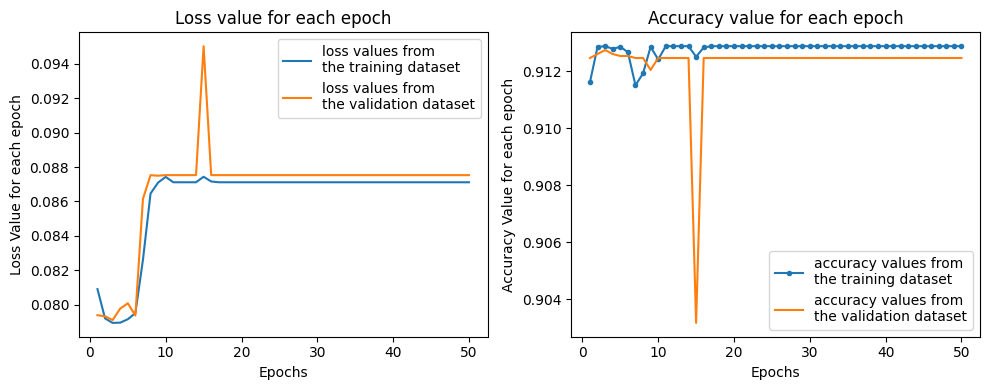

In [6]:
# Define the tuner function to create a TF binary logistic regression model
def model_tuner(hp):
  tf.keras.backend.clear_session()
  tuner = tf.keras.Sequential()

  # Input layer
  tuner.add(tf.keras.Input(shape=(X_train_tf.shape[1],)))   # Input Dim

  # Hidden layers
  for i in range(hp.Int("num_layers", min_value=1, max_value=3)):
    tuner.add(tf.keras.layers.Dense(units=hp.Int(f"units_{i}", min_value=16, max_value=128, step=16),
                                    activation=hp.Choice(f"activation_{i}", values=['relu', 'tanh', 'sigmoid'])))

  # Output layer
  tuner.add(tf.keras.layers.Dense(units=1,                  # Output dim
                                  use_bias=True,            # Use a bias (intercept) param
                                  activation='sigmoid',     # Using sigmoid for binary classification
                                  kernel_initializer='glorot_uniform',
                                  bias_initializer='zeros'))

  # Learning rate tuning
  learning_rate = hp.Float('learning_rate', min_value=0.0001, max_value=0.5, sampling='log')

  # Optimizer tuning
  optimizer_choice = hp.Choice('optimizer', ['adam', 'sgd'])
  if optimizer_choice == 'adam':
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
  elif optimizer_choice == 'sgd':
    optimizer = tf.keras.optimizers.SGD(learning_rate=learning_rate)
  
  # Compile and return the tuner
  tuner.compile(optimizer=optimizer, 
                loss=hp.Choice('loss', ['binary_crossentropy', 'mse']),
                metrics=['accuracy'])
  return tuner

# Hyperparameter Tuning
tuner = kt.RandomSearch(model_tuner,
                        objective='val_loss',
                        max_trials=10)
tuner.search(X_train_tf, Y_train_tf,
             validation_data=(X_val_tf, Y_val_tf),
             epochs=50,
             verbose=2)
hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f'The best hyperparameters are:\n{hyperparameters}')

# Create and fit the model on the training dataset
model_tf = tuner.hypermodel.build(hyperparameters)
history = model_tf.fit(X_train_tf, Y_train_tf,
                       validation_data=(X_val_tf, Y_val_tf),
                       epochs=50,
                       verbose = False)
print(f"\nAccuracy on the training dataset: {history.history['accuracy'][-1]:.2%}")
print(f"Accuracy on the validation dataset: {history.history['val_accuracy'][-1]:.2%}")

# Generate a plot
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot([i+1 for i in range(len(history.history['loss']))],
           history.history['loss'],
           label='loss values from \nthe training dataset')
ax[0].plot([i+1 for i in range(len(history.history['val_loss']))],
           history.history['val_loss'],
           label='loss values from \nthe validation dataset')
ax[1].plot([i+1 for i in range(len(history.history['accuracy']))],
           history.history['accuracy'],
           label='accuracy values from \nthe training dataset',
           marker='.') # To avoid overlap
ax[1].plot([i+1 for i in range(len(history.history['val_accuracy']))],
           history.history['val_accuracy'],
           label='accuracy values from \nthe validation dataset')

# Add title, axes, and legend
ax[0].set_title('Loss value for each epoch')
ax[1].set_title('Accuracy value for each epoch')
ax[0].set_xlabel('Epochs')
ax[1].set_xlabel('Epochs')
ax[0].set_ylabel('Loss Value for each epoch')
ax[1].set_ylabel('Accuracy Value for each epoch')
ax[0].legend()
ax[1].legend()
plt.tight_layout()
plt.show()

#### 2.1.2 Model evaluation with training and testing datasets

1341/1341 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
447/447 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step

The aggregate accuracy from the training dataset is: 91.29%
The aggregate accuracy from the testing dataset is: 90.89%


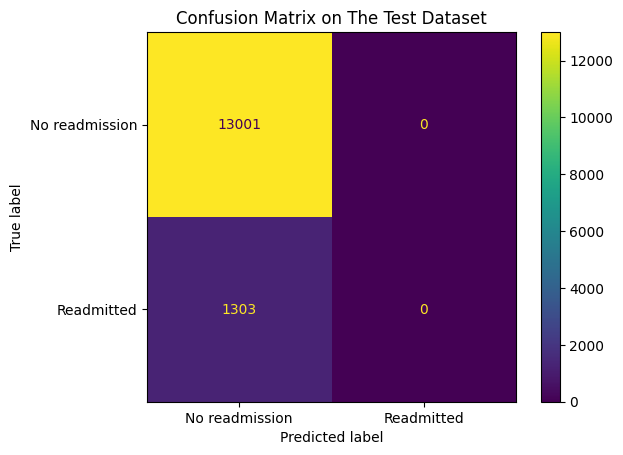

Precisions: 0.00%
False Positives: 0
Recalls: 0.00%
False Negatives: 1303

F1 score: 0.00%


In [7]:
# Calculate the predicted values
Y_train_hat_tf = (model_tf.predict(X_train_tf) >= 0.5).astype(int)
Y_test_hat_tf = (model_tf.predict(X_test_tf) >= 0.5).astype(int)

# Calculate accuracy values on both train and test datasets
accuracy_train_tf = accuracy_score(Y_train_tf, Y_train_hat_tf)
accuracy_test_tf = accuracy_score(Y_test_tf, Y_test_hat_tf)
print(f'\nThe aggregate accuracy from the training dataset is: {accuracy_train_tf:.2%}')
print(f'The aggregate accuracy from the testing dataset is: {accuracy_test_tf:.2%}')


# Plot the confusion matrix
cm_tf = confusion_matrix(Y_test_tf, Y_test_hat_tf)
disp = ConfusionMatrixDisplay(cm_tf, display_labels=['No readmission', 'Readmitted'])
disp.plot()
plt.grid(False) # Hide the white grid lines
plt.title('Confusion Matrix on The Test Dataset')
plt.show()

# Evaluation from the confusion matrix
precision_tf = precision_score(Y_test_tf, Y_test_hat_tf)    # cm_tf[1][1]/cm_tf[:,1].sum()
recall_tf = recall_score(Y_test_tf, Y_test_hat_tf)          # cm_tf[1][1]/cm_tf[1].sum()
f1_tf = f1_score(Y_test_tf, Y_test_hat_tf)                  # 2 * precision_tf * recall_tf / (precision_tf + recall_tf)
print(f'Precisions: {precision_tf:.2%}')
print(f'False Positives: {cm_tf[0][1]}')
print(f'Recalls: {recall_tf:.2%}')
print(f'False Negatives: {cm_tf[1][0]}')
print(f'\nF1 score: {f1_tf:.2%}')

### 2.2 Random Forest Model

In [8]:
# Make copies from X&Y datasets
X_train_rf = X_train.copy()
Y_train_rf = Y_train.copy()
X_val_rf = X_val.copy()
Y_val_rf = Y_val.copy()
X_test_rf = X_test.copy()
Y_test_rf = Y_test.copy()

# Print the shapes for each dataset
print("(rf) Shape of X_train: ", X_train_rf.shape)
print("(rf) Shape of Y_train: ", Y_train_rf.shape)
print("(rf) Shape of X_val: ", X_val_rf.shape)
print("(rf) Shape of Y_val: ", Y_val_rf.shape)
print("(rf) Shape of X_test: ", X_test_rf.shape)
print("(rf) Shape of Y_test: ", Y_test_rf.shape)

(rf) Shape of X_train:  (42910, 42)
(rf) Shape of Y_train:  (42910,)
(rf) Shape of X_val:  (14304, 42)
(rf) Shape of Y_val:  (14304,)
(rf) Shape of X_test:  (14304, 42)
(rf) Shape of Y_test:  (14304,)


#### 2.2.1 Model development with training and validation datasets

In [9]:
# Hyperparameter Tuning
tuning_options_rf = {"n_estimators": [100, 200, 300],       # Number of trees
                     "max_depth": [6, 8, 12, 16],           # Maximum depth of each tree
                     "min_samples_split": [2, 5, 10]}       # Min samples to split for each step

# Create and fit the model on the training dataset
model_rf = RandomizedSearchCV(RandomForestClassifier(),                 # Estimator - Random Forest
                              param_distributions=tuning_options_rf,
                              n_iter=30,                                # Number of parameter settings sampled
                              n_jobs=-1,                                # Optimize CPU
                              scoring="f1")                             # Evaluation metric

clf_rf = model_rf.fit(X_train_rf, Y_train_rf)
print(f"Accuracy on the training dataset: {clf_rf.score(X_train_rf, Y_train_rf):.2%}")
print(f"Accuracy on the validation dataset: {clf_rf.score(X_val_rf, Y_val_rf):.2%}")

# Obtain the top 5 importance feature names and their importance scores
print("\nTop 5 important features:")
print(pd.DataFrame({"features": X_train_rf.columns,
                    "importance": clf_rf.best_estimator_.feature_importances_})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
    .head())

Accuracy on the training dataset: 0.00%
Accuracy on the validation dataset: 0.00%

Top 5 important features:
             features  importance
0    number_inpatient    0.227262
1    time_in_hospital    0.109638
2     num_medications    0.095393
3  num_lab_procedures    0.081175
4             age_mid    0.077949


#### 2.2.2 Model evaluation with training and testing datasets


The aggregate accuracy from the training dataset is: 91.29%
The aggregate accuracy from the testing dataset is: 90.89%

                precision    recall  f1-score   support

No readmission       0.91      1.00      0.95     13001
   Readmission       0.00      0.00      0.00      1303

      accuracy                           0.91     14304
     macro avg       0.45      0.50      0.48     14304
  weighted avg       0.83      0.91      0.87     14304



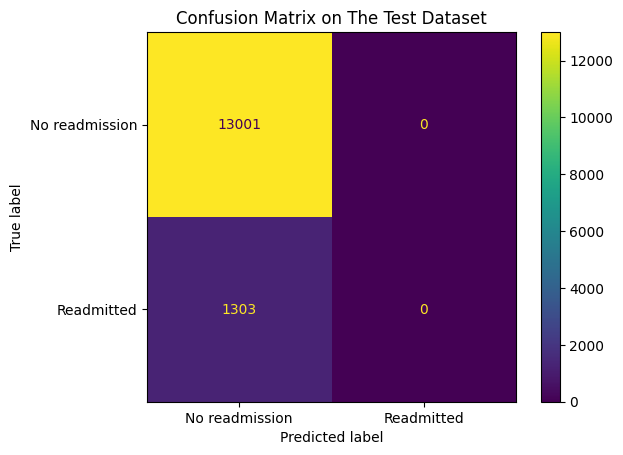

Precisions: 0.00%
False Positives: 0
Recalls: 0.00%
False Negatives: 1303

F1 score: 0.00%


In [10]:
# Calculate the predicted values
Y_train_hat_rf = model_rf.predict(X_train_rf)
Y_test_hat_rf = model_rf.predict(X_test_rf)

# Calculate accuracy values on both train and test datasets
accuracy_train_rf = accuracy_score(Y_train_rf, Y_train_hat_rf)
accuracy_test_rf = accuracy_score(Y_test_rf, Y_test_hat_rf)
print(f"\nThe aggregate accuracy from the training dataset is: {accuracy_train_rf:.2%}")
print(f"The aggregate accuracy from the testing dataset is: {accuracy_test_rf:.2%}", end="\n\n")
print(classification_report(Y_test_rf, Y_test_hat_rf, target_names=["No readmission", "Readmission"]))

# Plot the confusion matrix
cm_rf = confusion_matrix(Y_test_rf, Y_test_hat_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=["No readmission", "Readmitted"])
disp.plot()
plt.grid(False)  # Hide the white grid lines
plt.title("Confusion Matrix on The Test Dataset")
plt.show()

# Evaluation from the confusion matrix
precision_rf = precision_score(Y_test_rf, Y_test_hat_rf)    # cm_rf[1][1] / cm_rf[:, 1].sum()
recall_rf = recall_score(Y_test_rf, Y_test_hat_rf)          # cm_rf[1][1] / cm_rf[1].sum()
f1_rf = f1_score(Y_test_rf, Y_test_hat_rf)                  # 2 * precision_rf * recall_rf / (precision_rf + recall_rf)
print(f"Precisions: {precision_rf:.2%}")
print(f"False Positives: {cm_rf[0][1]}")
print(f"Recalls: {recall_rf:.2%}")
print(f"False Negatives: {cm_rf[1][0]}")
print(f"\nF1 score: {f1_rf:.2%}")

### 2.3 XGBoost Model

In [11]:
# Make copies from X&Y datasets
X_train_xgb = X_train.copy()
Y_train_xgb = Y_train.copy()
X_val_xgb = X_val.copy()
Y_val_xgb = Y_val.copy()
X_test_xgb = X_test.copy()
Y_test_xgb = Y_test.copy()

# Print the shapes for each dataset
print("(xgb) Shape of X_train: ", X_train_xgb.shape)
print("(xgb) Shape of Y_train: ", Y_train_xgb.shape)
print("(xgb) Shape of X_val: ", X_val_xgb.shape)
print("(xgb) Shape of Y_val: ", Y_val_xgb.shape)
print("(xgb) Shape of X_test: ", X_test_xgb.shape)
print("(xgb) Shape of Y_test: ", Y_test_xgb.shape)

(xgb) Shape of X_train:  (42910, 42)
(xgb) Shape of Y_train:  (42910,)
(xgb) Shape of X_val:  (14304, 42)
(xgb) Shape of Y_val:  (14304,)
(xgb) Shape of X_test:  (14304, 42)
(xgb) Shape of Y_test:  (14304,)


#### 2.3.1 Model development with training and validation datasets

In [12]:
# Hyperparameter Tuning
tuning_options_xgb = {"n_estimators": [30, 50, 100, 200, 300, 500],     # Number of boosting rounds
                      "max_depth": [3, 6, 8, 12, 16],                   # Maximum depth of each tree
                      "learning_rate": [0.01, 0.05, 0.1, 0.2, 0.4],     # Step size shrinkage
                      "subsample": [0.6, 0.8, 1.0],
                      "colsample_bytree": [0.6, 0.8, 1.0],
                      "gamma": [0, 0.1, 0.2, 0.3],
                      "min_child_weight": [1, 3, 5, 7]}

# Create and fit the model on the training dataset
model_xgb = RandomizedSearchCV(XGBClassifier(objective='binary:logistic',
                                             eval_metric='logloss',
                                             use_label_encoder=False,
                                             scale_pos_weight=len(Y_train[Y_train==0]) / len(Y_train[Y_train==1])),     # Estimator - XGBoost
                              param_distributions=tuning_options_xgb,
                              n_iter=30,        # Number of parameter settings sampled
                              n_jobs=-1,        # Optimize CPU
                              scoring='f1')     # Evaluation metric


clf_xgb = model_xgb.fit(X_train_xgb, Y_train_xgb)
print(f"Accuracy on the training dataset: {clf_xgb.score(X_train_xgb, Y_train_xgb):.2%}")
print(f"Accuracy on the validation dataset: {clf_xgb.score(X_val_xgb, Y_val_xgb):.2%}")

# Obtain the top 5 importance feature names and their importance scores
print("\nTop 5 important features:")
print(pd.DataFrame({"features": X_train_xgb.columns,
                    "importance": clf_xgb.best_estimator_.feature_importances_})
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
    .head())

Accuracy on the training dataset: 20.76%
Accuracy on the validation dataset: 18.97%

Top 5 important features:
           features  importance
0  number_inpatient    0.111578
1  time_in_hospital    0.073876
2  race_collapsed_?    0.055643
3       diabetesMed    0.053489
4           age_mid    0.048343


#### 2.3.2 Model evaluation with training and testing datasets


The aggregate accuracy from the training dataset is: 60.99%
The aggregate accuracy from the testing dataset is: 60.49%

                precision    recall  f1-score   support

No readmission       0.93      0.61      0.74     13001
   Readmission       0.12      0.55      0.20      1303

      accuracy                           0.60     14304
     macro avg       0.53      0.58      0.47     14304
  weighted avg       0.86      0.60      0.69     14304



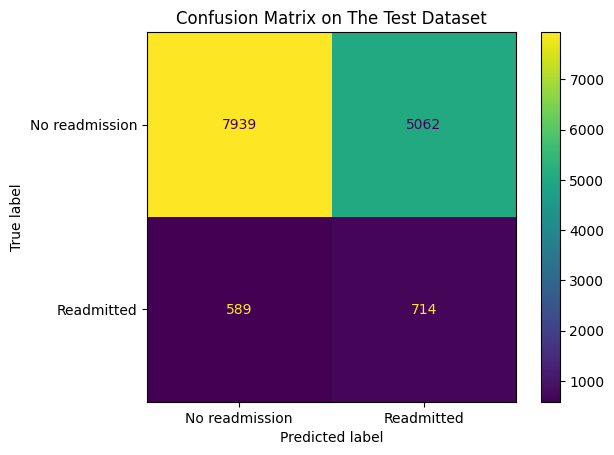

Precisions: 12.36%
False Positives: 5062
Recalls: 54.80%
False Negatives: 589

F1 score: 20.17%


In [13]:
# Calculate the predicted values
Y_train_hat_xgb = model_xgb.predict(X_train_xgb)
Y_test_hat_xgb = model_xgb.predict(X_test_xgb)

# Calculate accuracy values on both train and test datasets
accuracy_train_xgb = accuracy_score(Y_train_xgb, Y_train_hat_xgb)
accuracy_test_xgb = accuracy_score(Y_test_xgb, Y_test_hat_xgb)
print(f"\nThe aggregate accuracy from the training dataset is: {accuracy_train_xgb:.2%}")
print(f"The aggregate accuracy from the testing dataset is: {accuracy_test_xgb:.2%}", end="\n\n")
print(classification_report(Y_test_xgb, Y_test_hat_xgb, target_names=["No readmission", "Readmission"]))

# Plot the confusion matrix
cm_xgb = confusion_matrix(Y_test_xgb, Y_test_hat_xgb)
disp = ConfusionMatrixDisplay(cm_xgb, display_labels=["No readmission", "Readmitted"])
disp.plot()
plt.grid(False)  # Hide the white grid lines
plt.title("Confusion Matrix on The Test Dataset")
plt.show()

# Evaluation from the confusion matrix
precision_xgb = precision_score(Y_test_xgb, Y_test_hat_xgb)     # cm_xgb[1][1] / cm_xgb[:, 1].sum()
recall_xgb = recall_score(Y_test_xgb, Y_test_hat_xgb)           # cm_xgb[1][1] / cm_xgb[1].sum()
f1_xgb = f1_score(Y_test_xgb, Y_test_hat_xgb)                   # 2 * precision_xgb * recall_xgb / (precision_xgb + recall_xgb)
print(f"Precisions: {precision_xgb:.2%}")
print(f"False Positives: {cm_xgb[0][1]}")
print(f"Recalls: {recall_xgb:.2%}")
print(f"False Negatives: {cm_xgb[1][0]}")
print(f"\nF1 score: {f1_xgb:.2%}")

## 3. Notebook Exports

#### 3.1 Export models

In [14]:
# Export the three models into results/
joblib.dump(model_tf, '../results/terra_tf.pkl')
joblib.dump(model_rf, "../results/terra_rf.pkl")
joblib.dump(model_xgb, "../results/terra_xgb.pkl")

['../results/terra_xgb.pkl']

#### 3.2 Export evaluation results

In [15]:
# Initialize the dataframe
stats = pd.DataFrame(columns=["feature_importance",
                              "precision",
                              "recall",
                              "false_positive",
                              "false_negative",
                              "final_accuracy_train",
                              "final_accuracy_test",
                              "f1"])

# Insert model statistics from random forest and xgboost
stats_tf = pd.DataFrame([{"feature_importance": None,
                          "precision": precision_tf,
                          "recall": recall_tf,
                          "false_positive": cm_tf[0][1],
                          "false_negative": cm_tf[1][0],
                          "final_accuracy_train": accuracy_train_tf,
                          "final_accuracy_test": accuracy_test_tf,
                          "f1": f1_tf}])
stats_rf = pd.DataFrame([{"feature_importance": clf_rf.best_estimator_.feature_importances_,  # Force importance values to be included in one row
                          "precision": precision_rf,
                          "recall": recall_rf,
                          "false_positive": cm_rf[0][1],
                          "false_negative": cm_rf[1][0],
                          "final_accuracy_train": accuracy_train_rf,
                          "final_accuracy_test": accuracy_test_rf,
                          "f1": f1_rf}])
stats_xgb = pd.DataFrame([{"feature_importance": clf_xgb.best_estimator_.feature_importances_,  # Force importance values to be included in one row
                           "precision": precision_xgb,
                           "recall": recall_xgb,
                           "false_positive": cm_xgb[0][1],
                           "false_negative": cm_xgb[1][0],
                           "final_accuracy_train": accuracy_train_xgb,
                           "final_accuracy_test": accuracy_test_xgb,
                           "f1": f1_xgb}])

# Combine the stats and export as csv
stats = pd.concat([stats, stats_tf, stats_rf, stats_xgb], ignore_index=True)
stats.to_csv("../results/terra_stats_tf_rf_xgb.csv", index=False)